# Entrenar YOLOv8 con anotaciones de LabelImg (Pascal VOC -> YOLO)

Entrena un detector de objetos sobre las imagenes IR etiquetadas en `DATASET_BILLS_IR_sample`.
Luego aplica el modelo al dataset completo para auto-etiquetar generando XML Pascal VOC.

---
## Flujo
1. Convertir XML (Pascal VOC) a formato YOLO (.txt)
2. Dividir en train/val
3. Entrenar YOLOv8
4. Evaluar
5. Inferir sobre todo DATASET_BILLS_IR y guardar XML Pascal VOC + imagenes originales
---

In [1]:
# ============================================================
# 1. DEPENDENCIAS
# ============================================================
# Descomenta si es primera vez:
# !pip install ultralytics torch torchvision matplotlib seaborn scikit-learn tqdm

In [2]:
from pathlib import Path
import xml.etree.ElementTree as ET
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from collections import Counter

from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
print("Librerias cargadas")

Librerias cargadas


---
## 2. Configuracion
---

In [3]:
# ============================================================
# 2. CONFIGURACION
# ============================================================

SAMPLE_DIR = Path("../Data/raw/IR_por_billete")
FULL_DATASET_DIR = Path("../Data/raw/DATASET_BILLS_IR")
DATASET_OUT = Path("../Data/procesed/yolo_sample_dataset")
MODELS_DIR = Path("../Models").resolve()
PREDICTIONS_DIR = Path("../Data/procesed/predictions_auto")

IMG_SIZE = 640
BATCH_SIZE = 32
EPOCHS = 80
TRAIN_SPLIT = 0.8
MODEL_SIZE = "n"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Sample: {SAMPLE_DIR}")
print(f"Dataset completo: {FULL_DATASET_DIR}")
print(f"Salida YOLO: {DATASET_OUT}")
print(f"Modelos: {MODELS_DIR}")
print(f"Predicciones: {PREDICTIONS_DIR}")

Sample: ../Data/raw/IR_por_billete
Dataset completo: ../Data/raw/DATASET_BILLS_IR
Salida YOLO: ../Data/procesed/yolo_sample_dataset
Modelos: /Users/adamleanos/Projecto ia - detector de billetes/Models
Predicciones: ../Data/procesed/predictions_auto


In [4]:
# ============================================================
# CONVERTIR BMP A PNG (si hay)
# ============================================================
from PIL import Image
from pathlib import Path

for carpeta in [Path("../Data/raw/DATASET_BILLS_IR"), Path("../Data/raw/DATASET_BILLS_IR_sample")]:
    bmps = list(carpeta.rglob("*.bmp")) + list(carpeta.rglob("*.BMP"))
    if bmps:
        print(f"Convirtiendo {len(bmps)} BMP en {carpeta.name}...")
        for bmp in bmps:
            img = Image.open(bmp)
            png_path = bmp.with_suffix(".png")
            img.save(str(png_path))
            bmp.unlink()
        print(f"  OK")
    else:
        print(f"{carpeta.name}: sin BMPs")

print("Verificacion completada")

DATASET_BILLS_IR: sin BMPs
DATASET_BILLS_IR_sample: sin BMPs
Verificacion completada


---
## 3. Extraer clases desde XML
---

In [5]:
# ============================================================
# 3. EXTRAER CLASES
# ============================================================

def get_all_classes(sample_dir):
    classes = set()
    for xml_file in sorted(sample_dir.rglob("*.xml")):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        for obj in root.findall(".//object"):
            classes.add(obj.find("name").text)
    return sorted(classes)

CLASSES = get_all_classes(SAMPLE_DIR)
NUM_CLASSES = len(CLASSES)
CLS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

print(f"Total clases: {NUM_CLASSES}")
for i, c in enumerate(CLASSES):
    print(f"  {i}: {c}")

Total clases: 0


---
## 4. Convertir XML a YOLO y preparar dataset
---

In [6]:
# ============================================================
# 4. CONVERTIR VOC -> YOLO y DIVIDIR
# ============================================================

def voc_to_yolo(xml_path, cls_to_id):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    w = int(root.find(".//size/width").text)
    h = int(root.find(".//size/height").text)
    labels = []
    for obj in root.findall(".//object"):
        name = obj.find("name").text
        if name not in cls_to_id:
            continue
        cls_id = cls_to_id[name]
        xmin = int(obj.find(".//bndbox/xmin").text)
        ymin = int(obj.find(".//bndbox/ymin").text)
        xmax = int(obj.find(".//bndbox/xmax").text)
        ymax = int(obj.find(".//bndbox/ymax").text)
        cx = (xmin + xmax) / 2 / w
        cy = (ymin + ymax) / 2 / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h
        labels.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    return labels


def preparar_dataset_yolo(sample_dir, destino, cls_to_id, split=0.8, recursive=False):
    if destino.exists():
        print(f"{destino} ya existe. Eliminalo o cambia la ruta para regenerar.")
        return

    images_train = destino / "images/train"
    images_val = destino / "images/val"
    labels_train = destino / "labels/train"
    labels_val = destino / "labels/val"
    for d in [images_train, images_val, labels_train, labels_val]:
        d.mkdir(parents=True, exist_ok=True)

    todas = []
    if recursive:
        for img_path in sorted(sample_dir.rglob("*.png")):
            xml_path = img_path.with_suffix(".xml")
            if xml_path.exists():
                todas.append((img_path, xml_path))
    else:
        for denom_dir in sorted(sample_dir.iterdir()):
            if not denom_dir.is_dir():
                continue
            for img_path in sorted(denom_dir.glob("*.png")):
                xml_path = img_path.with_suffix(".xml")
                if xml_path.exists():
                    todas.append((img_path, xml_path))

    random.shuffle(todas)
    n_train = int(split * len(todas))

    for i, (img_path, xml_path) in enumerate(todas):
        prefix = "train" if i < n_train else "val"
        shutil.copy2(str(img_path), str(destino / f"images/{prefix}/{img_path.name}"))
        labels = voc_to_yolo(xml_path, cls_to_id)
        if labels:
            label_path = destino / f"labels/{prefix}/{img_path.stem}.txt"
            label_path.write_text("\n".join(labels))

    n_xml = len(todas)
    n_with_labels = sum(
        1 for _, xp in todas if len(voc_to_yolo(xp, cls_to_id)) > 0
    )
    print(f"Dataset listo en {destino}")
    print(f"  Train: {n_train} imagenes")
    print(f"  Val: {n_xml - n_train} imagenes")
    print(f"  Con anotaciones: {n_with_labels}/{n_xml}")


preparar_dataset_yolo(SAMPLE_DIR, DATASET_OUT, CLS_TO_ID, TRAIN_SPLIT)

../Data/procesed/yolo_sample_dataset ya existe. Eliminalo o cambia la ruta para regenerar.


---
## 5. Crear data.yaml
---

In [7]:
# ============================================================
# 5. DATA.YAML
# ============================================================

data_yaml = {
    "path": str(DATASET_OUT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "nc": NUM_CLASSES,
    "names": CLASSES,
}

yaml_path = DATASET_OUT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml creado en {yaml_path}")
print(yaml.dump(data_yaml, default_flow_style=False))

data.yaml creado en ../Data/procesed/yolo_sample_dataset/data.yaml
names: []
nc: 0
path: /Users/adamleanos/Projecto ia - detector de billetes/Data/procesed/yolo_sample_dataset
train: images/train
val: images/val



---
## 6. Visualizar anotaciones convertidas
---

IndexError: list index out of range

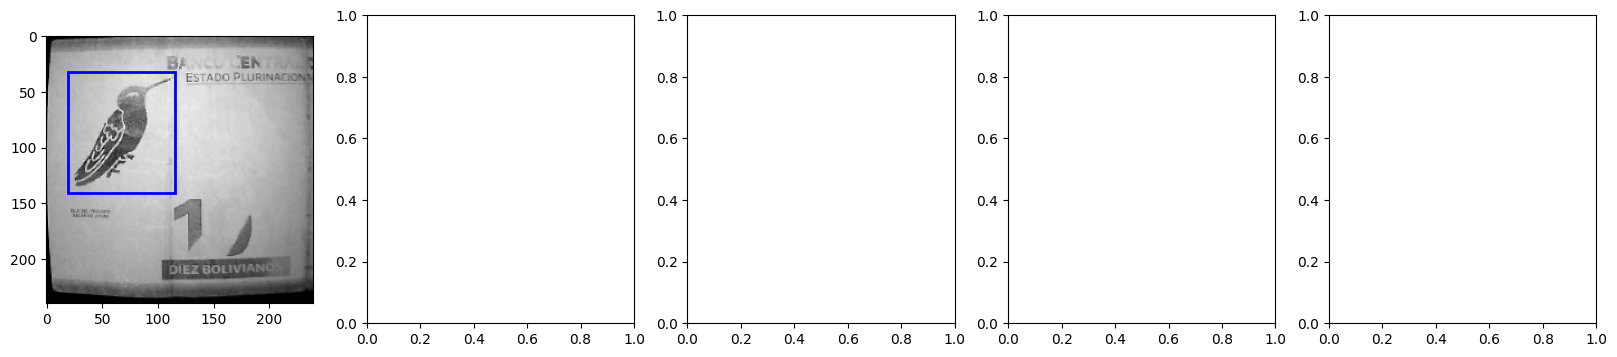

In [8]:
# ============================================================
# 6. VISUALIZAR ANOTACIONES
# ============================================================

def show_annotations(split="train", num=5):
    img_dir = DATASET_OUT / f"images/{split}"
    label_dir = DATASET_OUT / f"labels/{split}"
    imgs = sorted(img_dir.glob("*.png"))
    if not imgs:
        print(f"No hay imagenes en {img_dir}")
        return
    samples = random.sample(imgs, min(num, len(imgs)))

    fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
    if len(samples) == 1:
        axes = [axes]

    colors = [
        "red", "blue", "green", "orange", "purple", "cyan",
        "magenta", "brown", "pink", "olive", "navy",
    ]

    for ax, img_path in zip(axes, samples):
        img = Image.open(img_path).convert("L")
        ax.imshow(img, cmap="gray")
        h, w = img.size[1], img.size[0]

        label_file = label_dir / f"{img_path.stem}.txt"
        if label_file.exists():
            for line in label_file.read_text().strip().split("\n"):
                if not line:
                    continue
                parts = line.strip().split()
                cls_id, cx, cy, bw, bh = map(float, parts[:5])
                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                bx = int(bw * w)
                by = int(bh * h)
                c = colors[int(cls_id) % len(colors)]
                rect = plt.Rectangle(
                    (x1, y1), bx, by, fill=False, edgecolor=c, linewidth=2
                )
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 2, CLASSES[int(cls_id)],
                    color=c, fontsize=7, fontweight="bold",
                )
        ax.axis("off")

    plt.suptitle(f"Anotaciones - {split}")
    plt.tight_layout()
    plt.show()


show_annotations("train")
show_annotations("val")

---
## 7. Entrenar YOLOv8
---

In [ ]:
# ============================================================
# 7. ENTRENAR
# ============================================================
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
model = YOLO(f"yolov8{MODEL_SIZE}.pt")

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=320,
    batch=32,
    device="mps",
    patience=15,
    save=True,
    project=str(MODELS_DIR),
    name="yolo_sample_detector",
    exist_ok=True,
    plots=True,
    verbose=True, 
    optimizer='auto',
    #lr0=0.001,
    #lrf=0.01,
    #weight_decay=0.0005,
)
print("\nEntrenamiento completado")

Ultralytics 8.4.53 🚀 Python-3.8.20 torch-2.4.1 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../Data/procesed/yolo_sample_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_sample_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

---
## 8. Graficas de entrenamiento
---

Buscando graficas en: /Users/adamleanos/Projecto ia - detector de billetes/Models/yolo_sample_detector


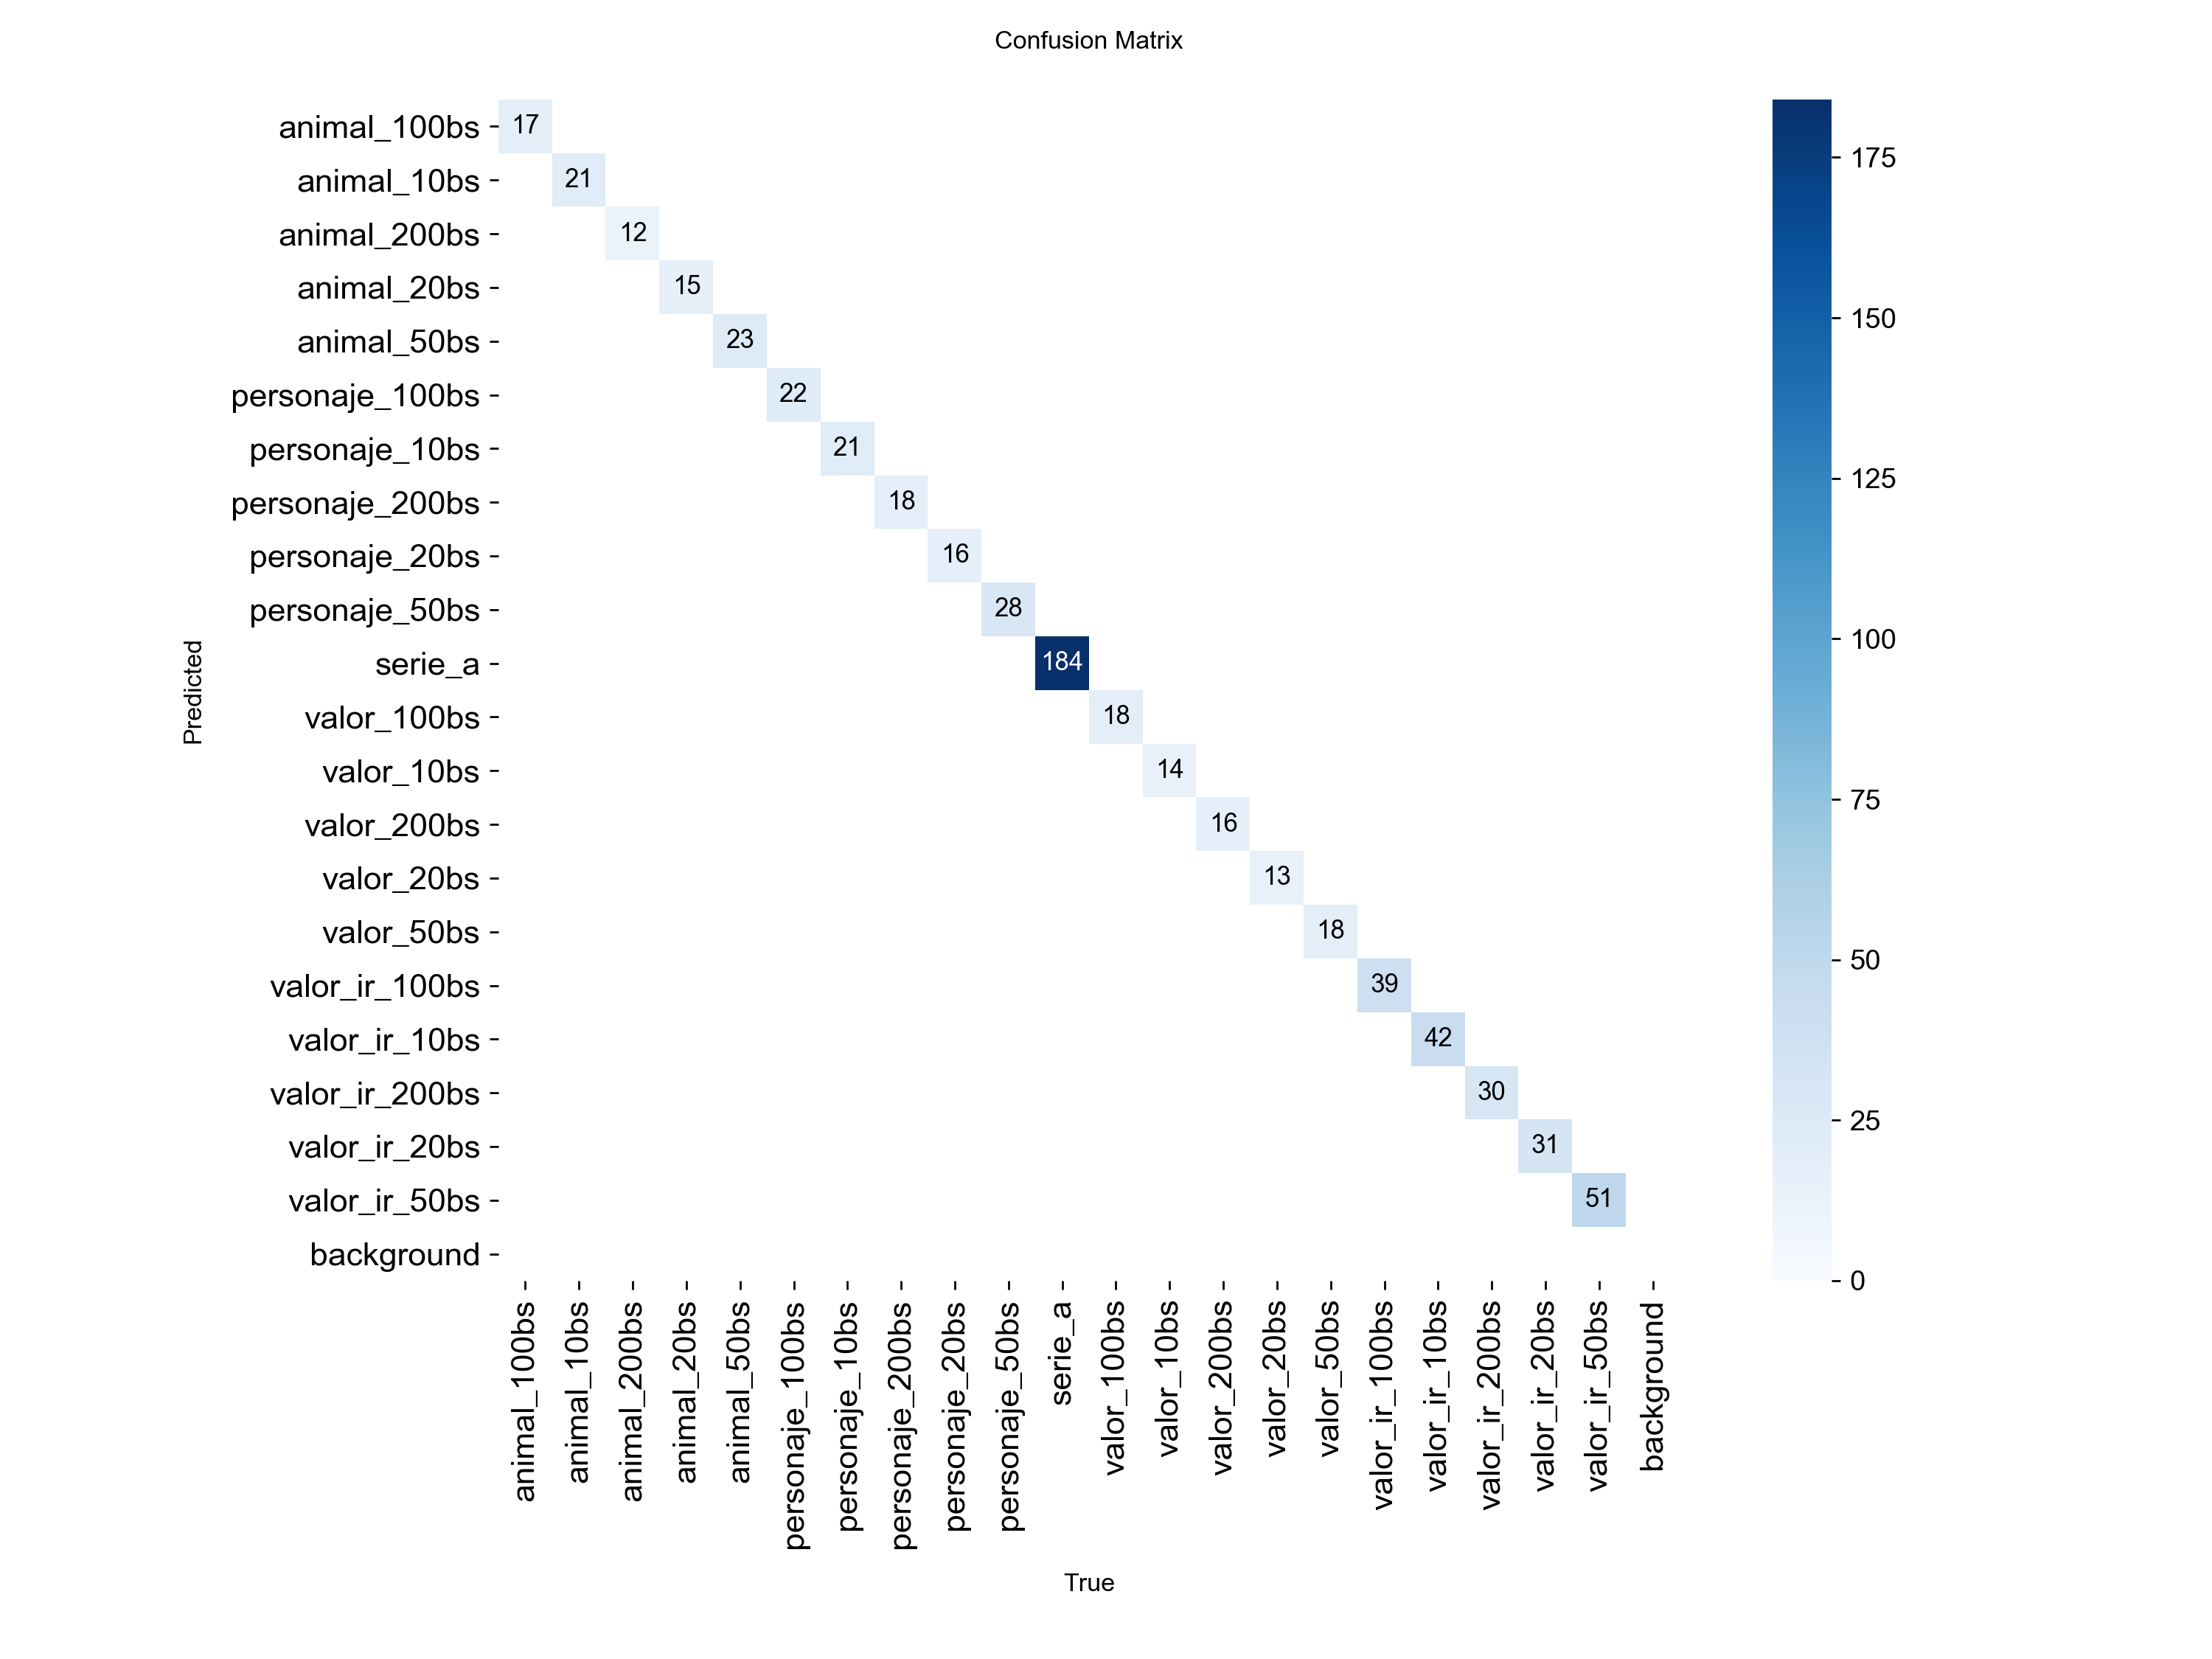

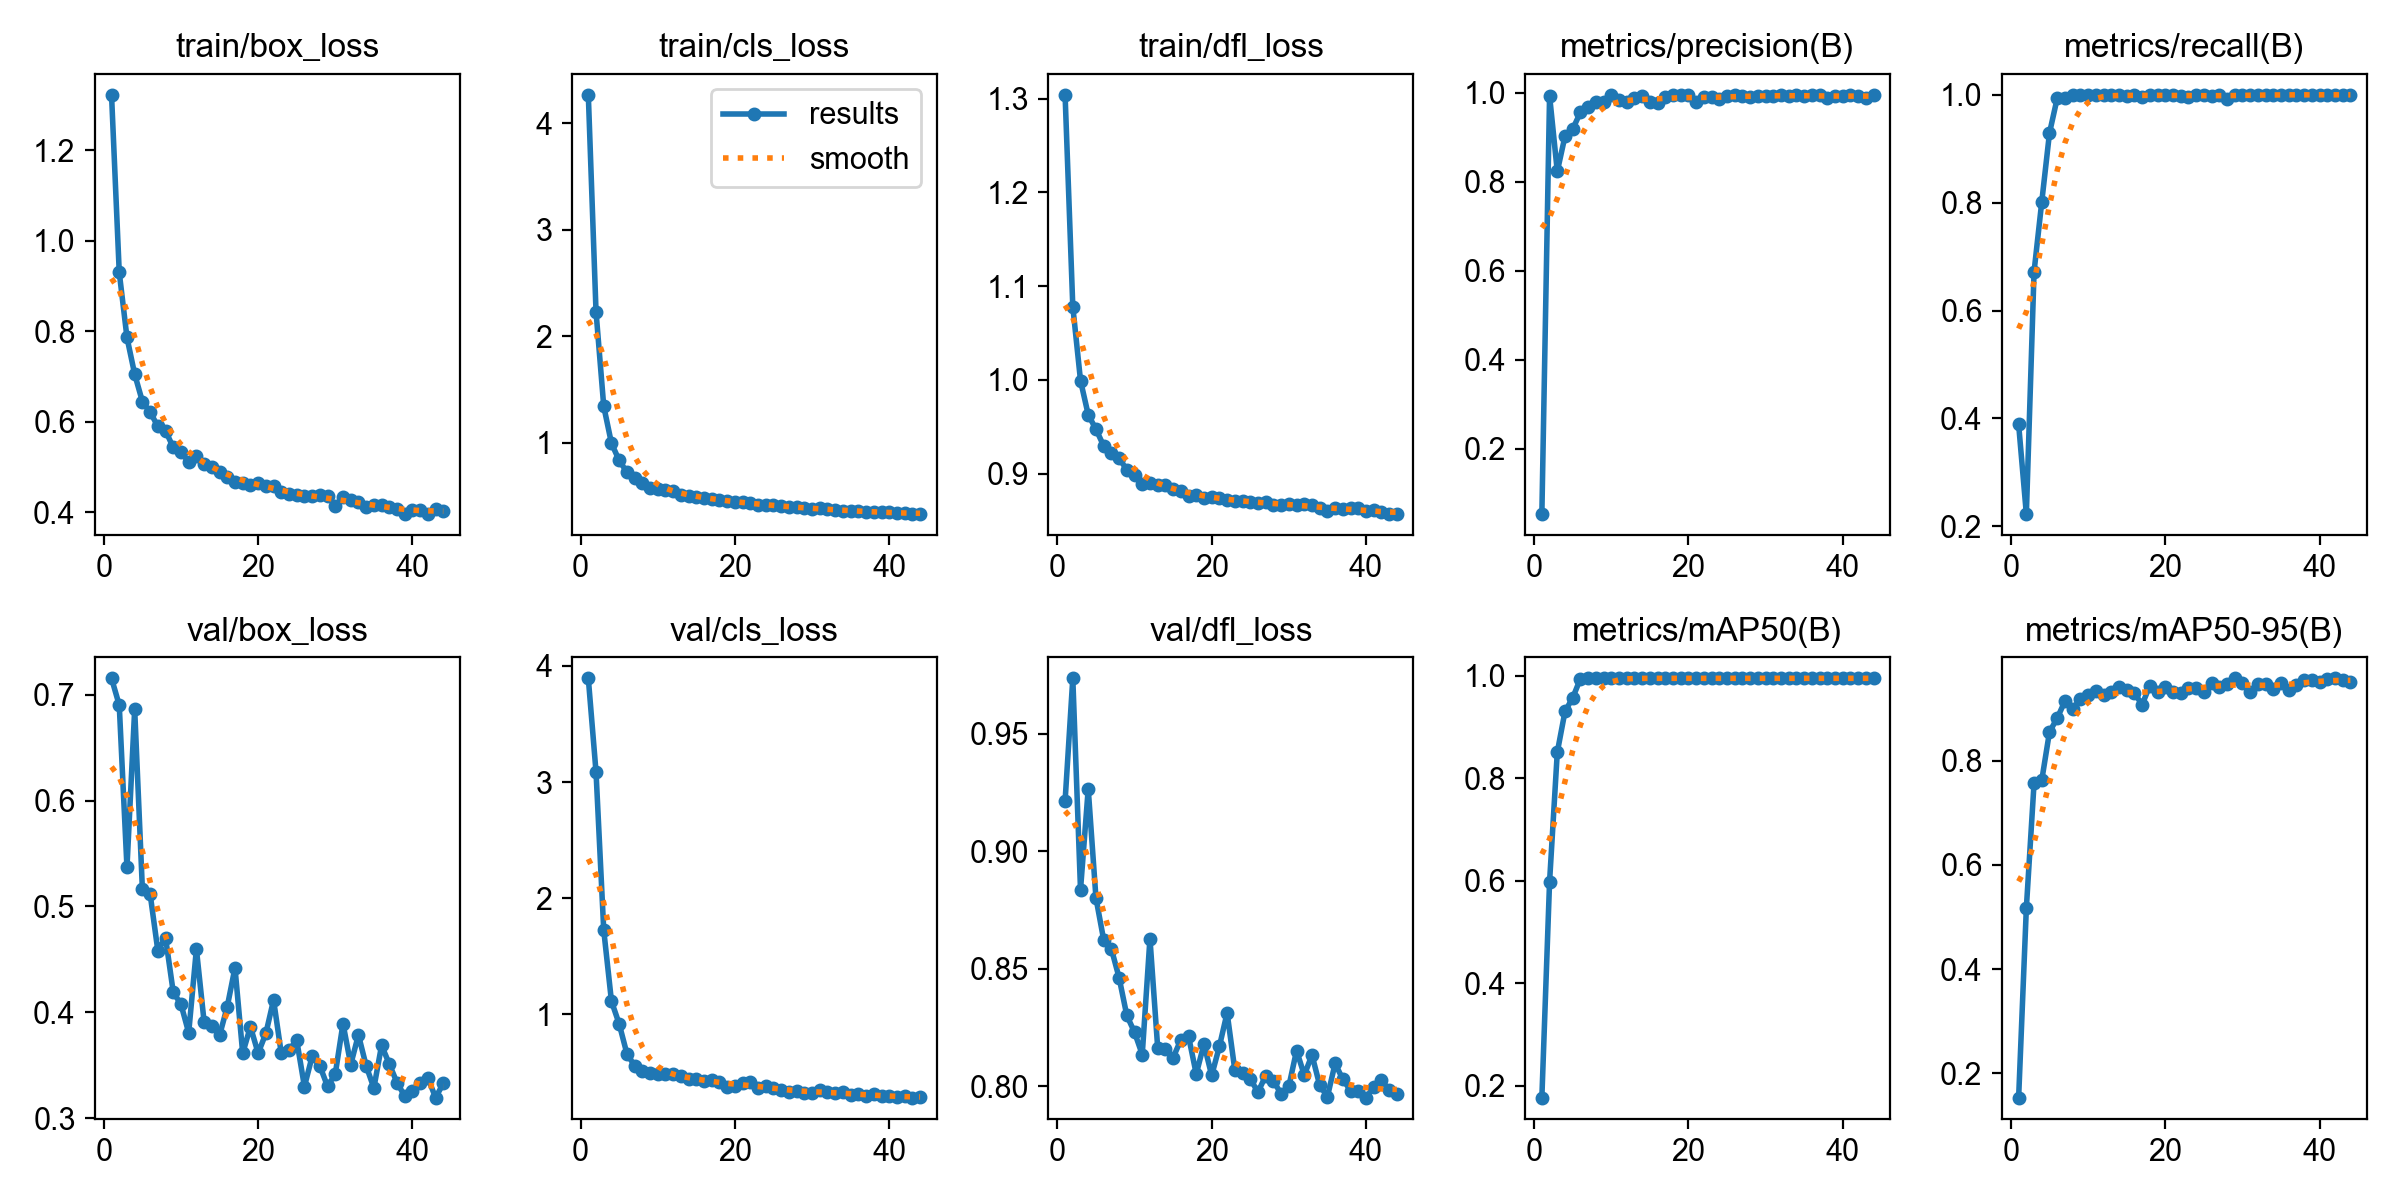

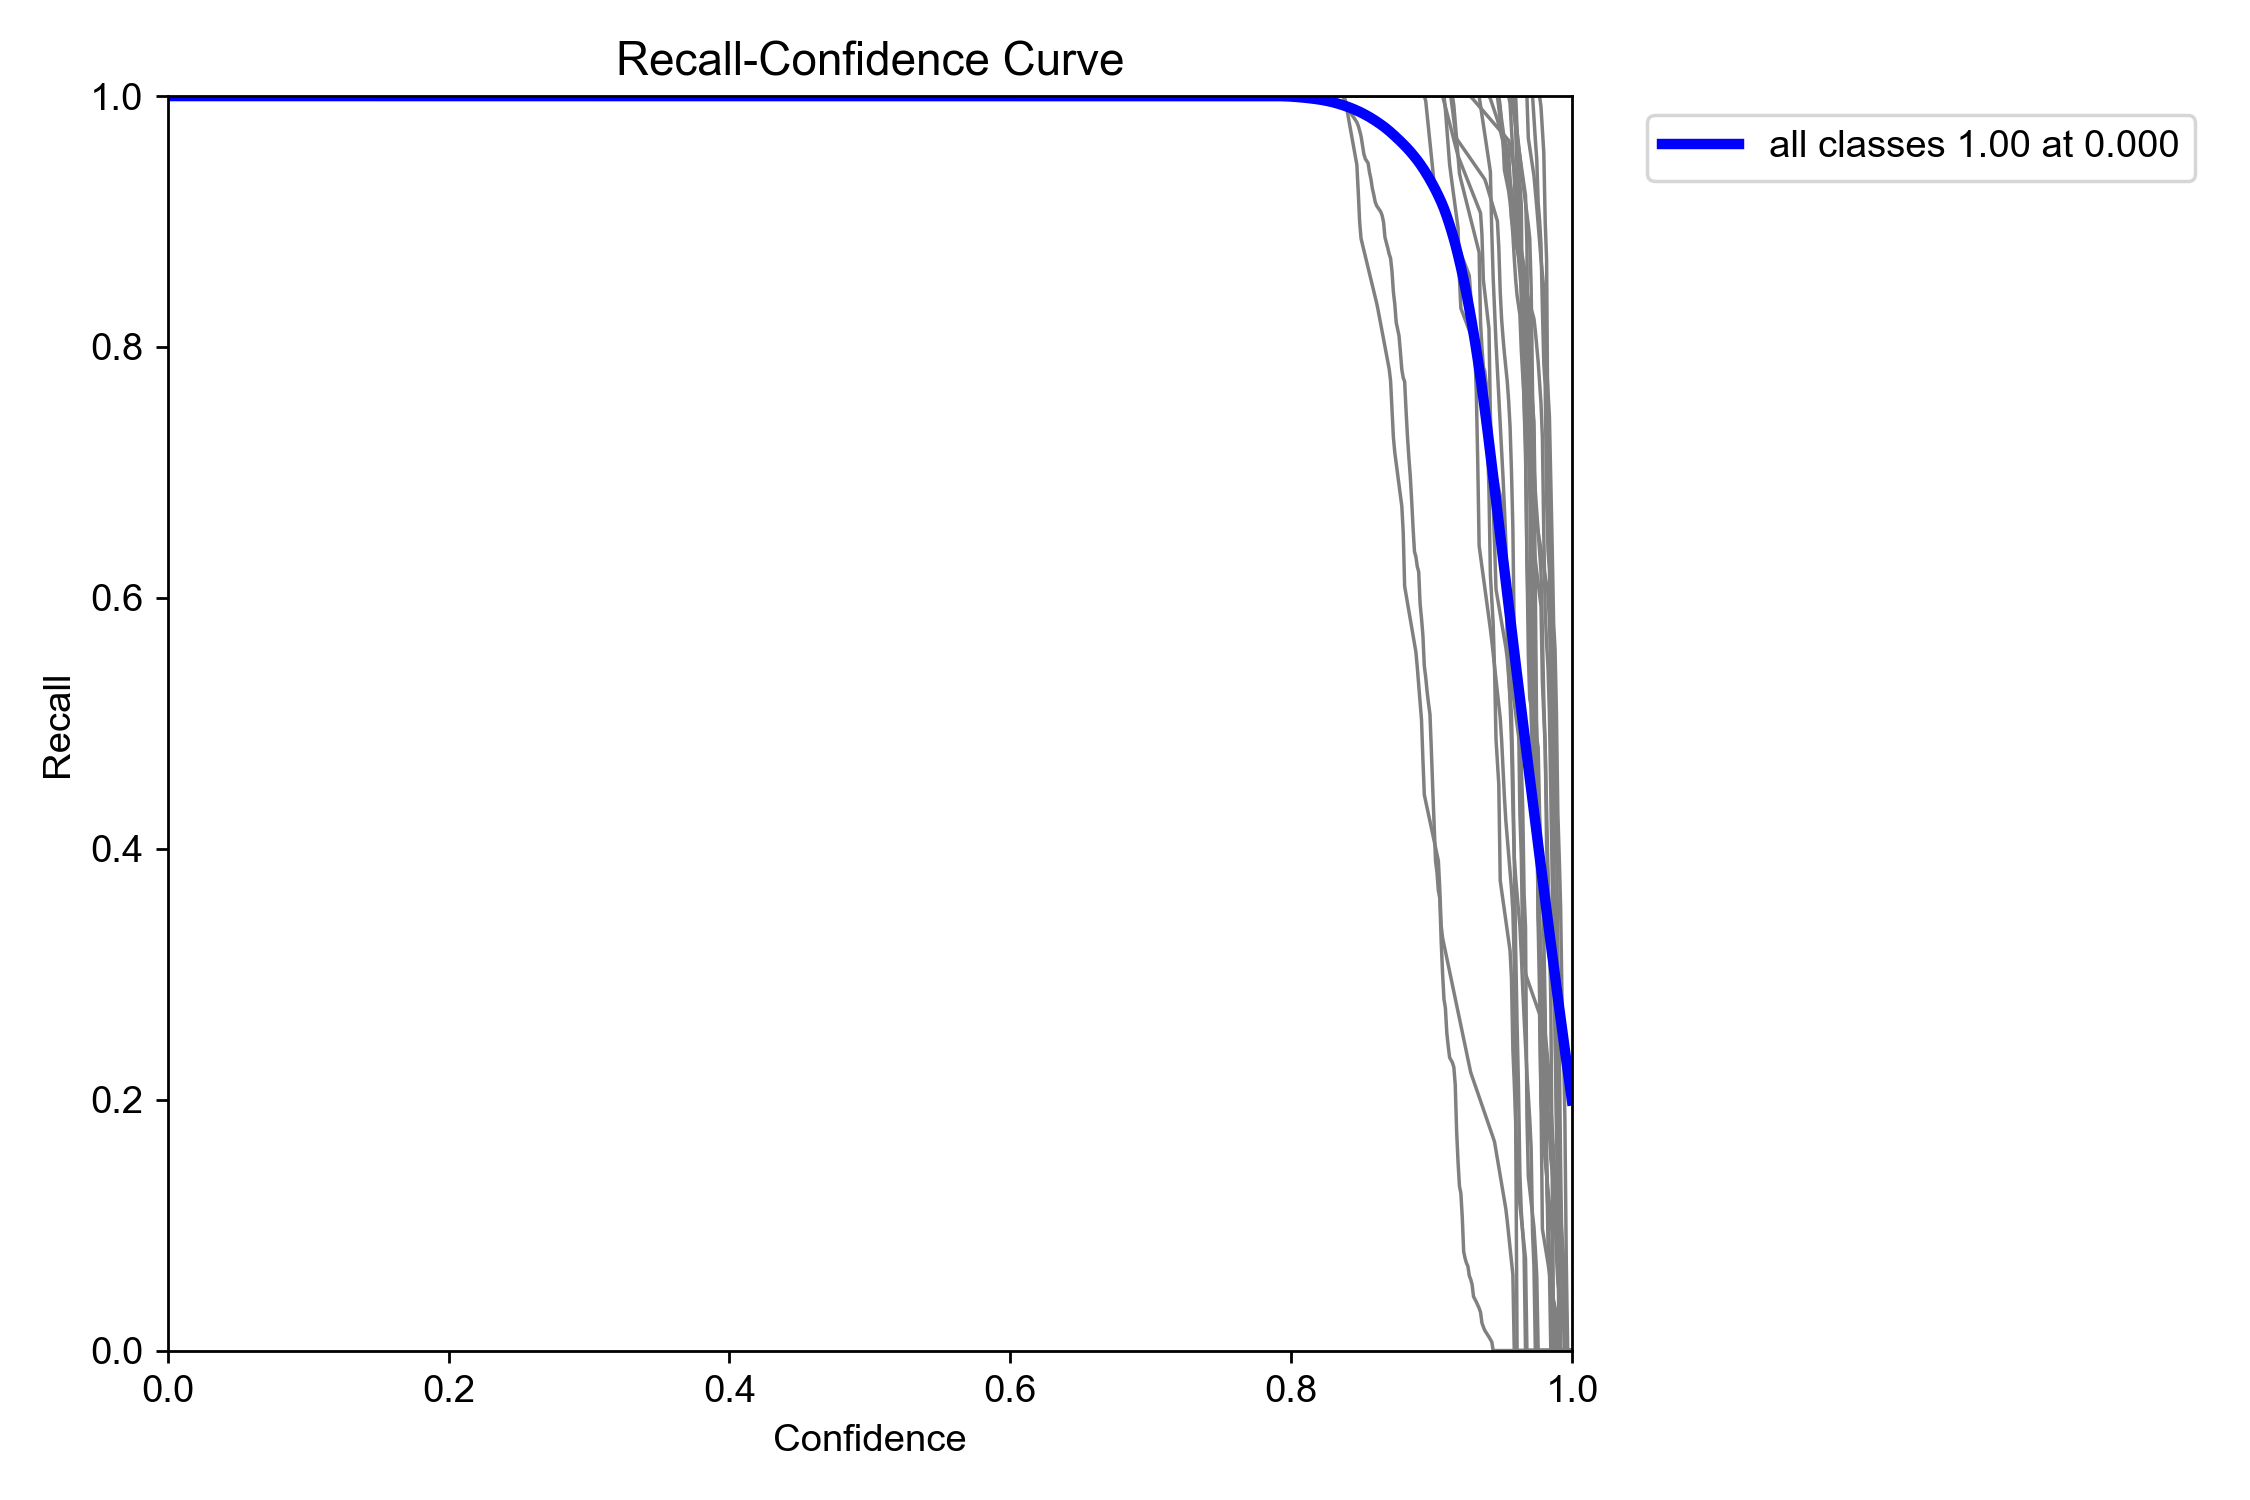

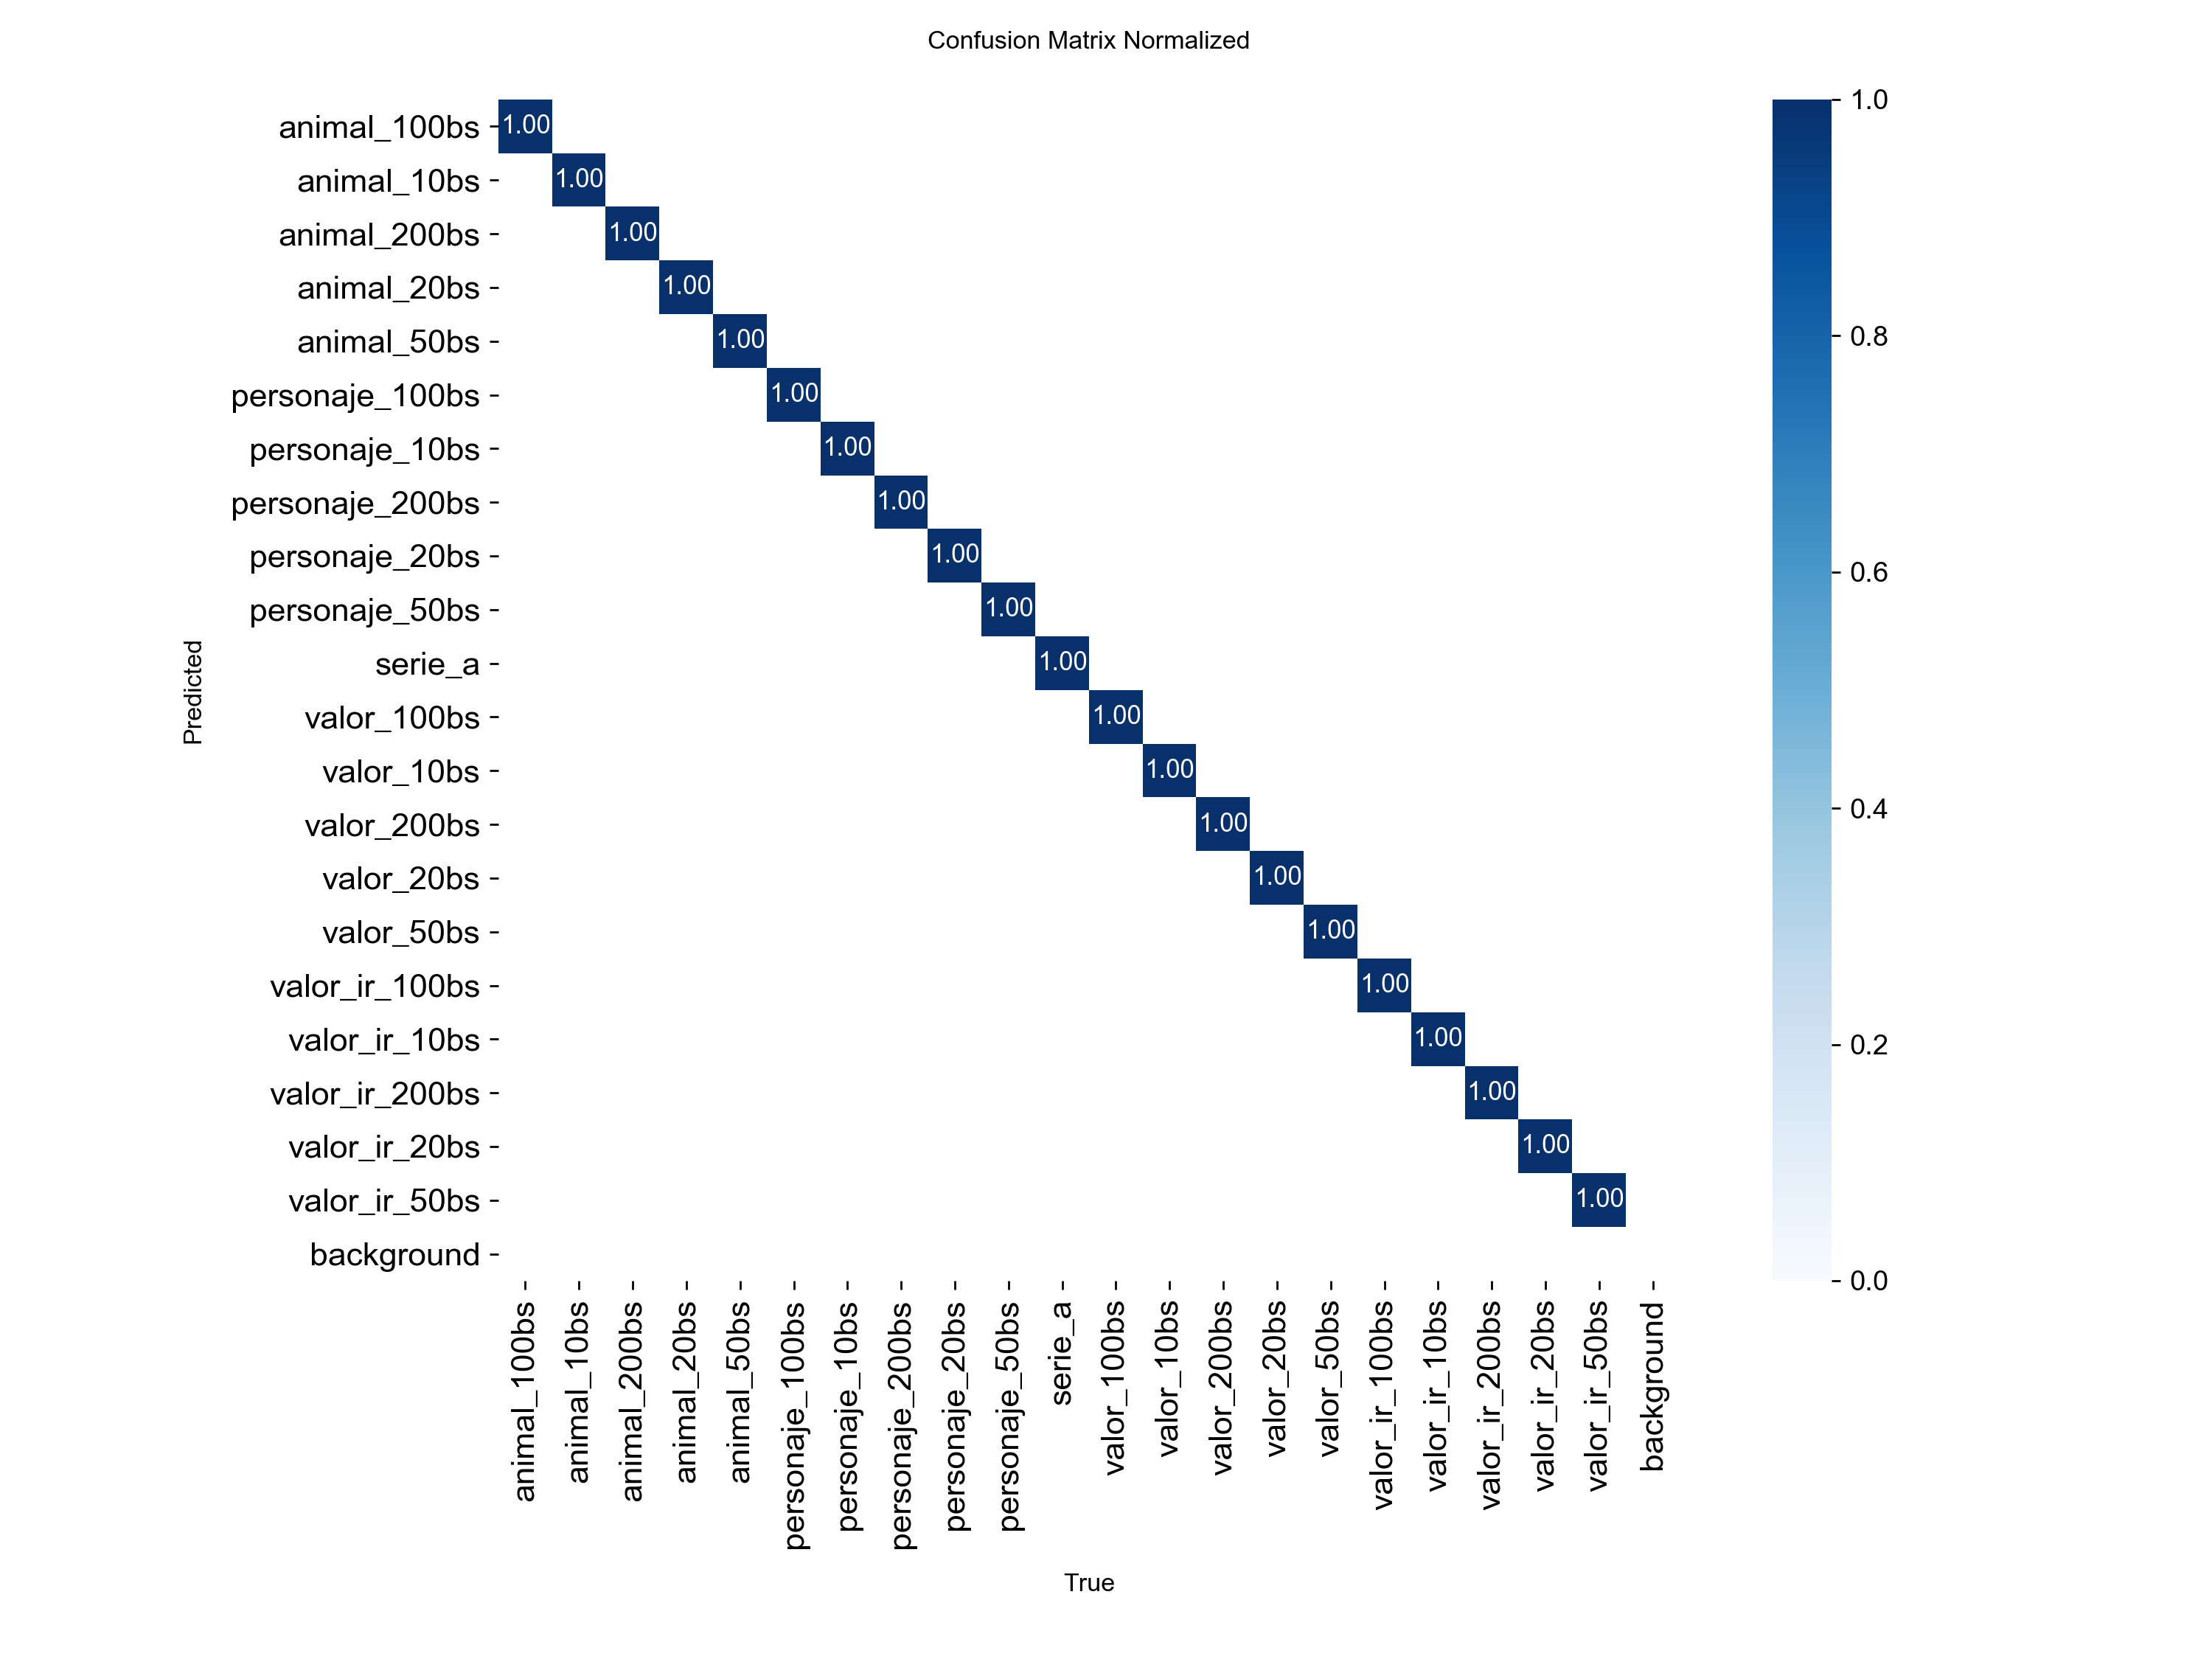

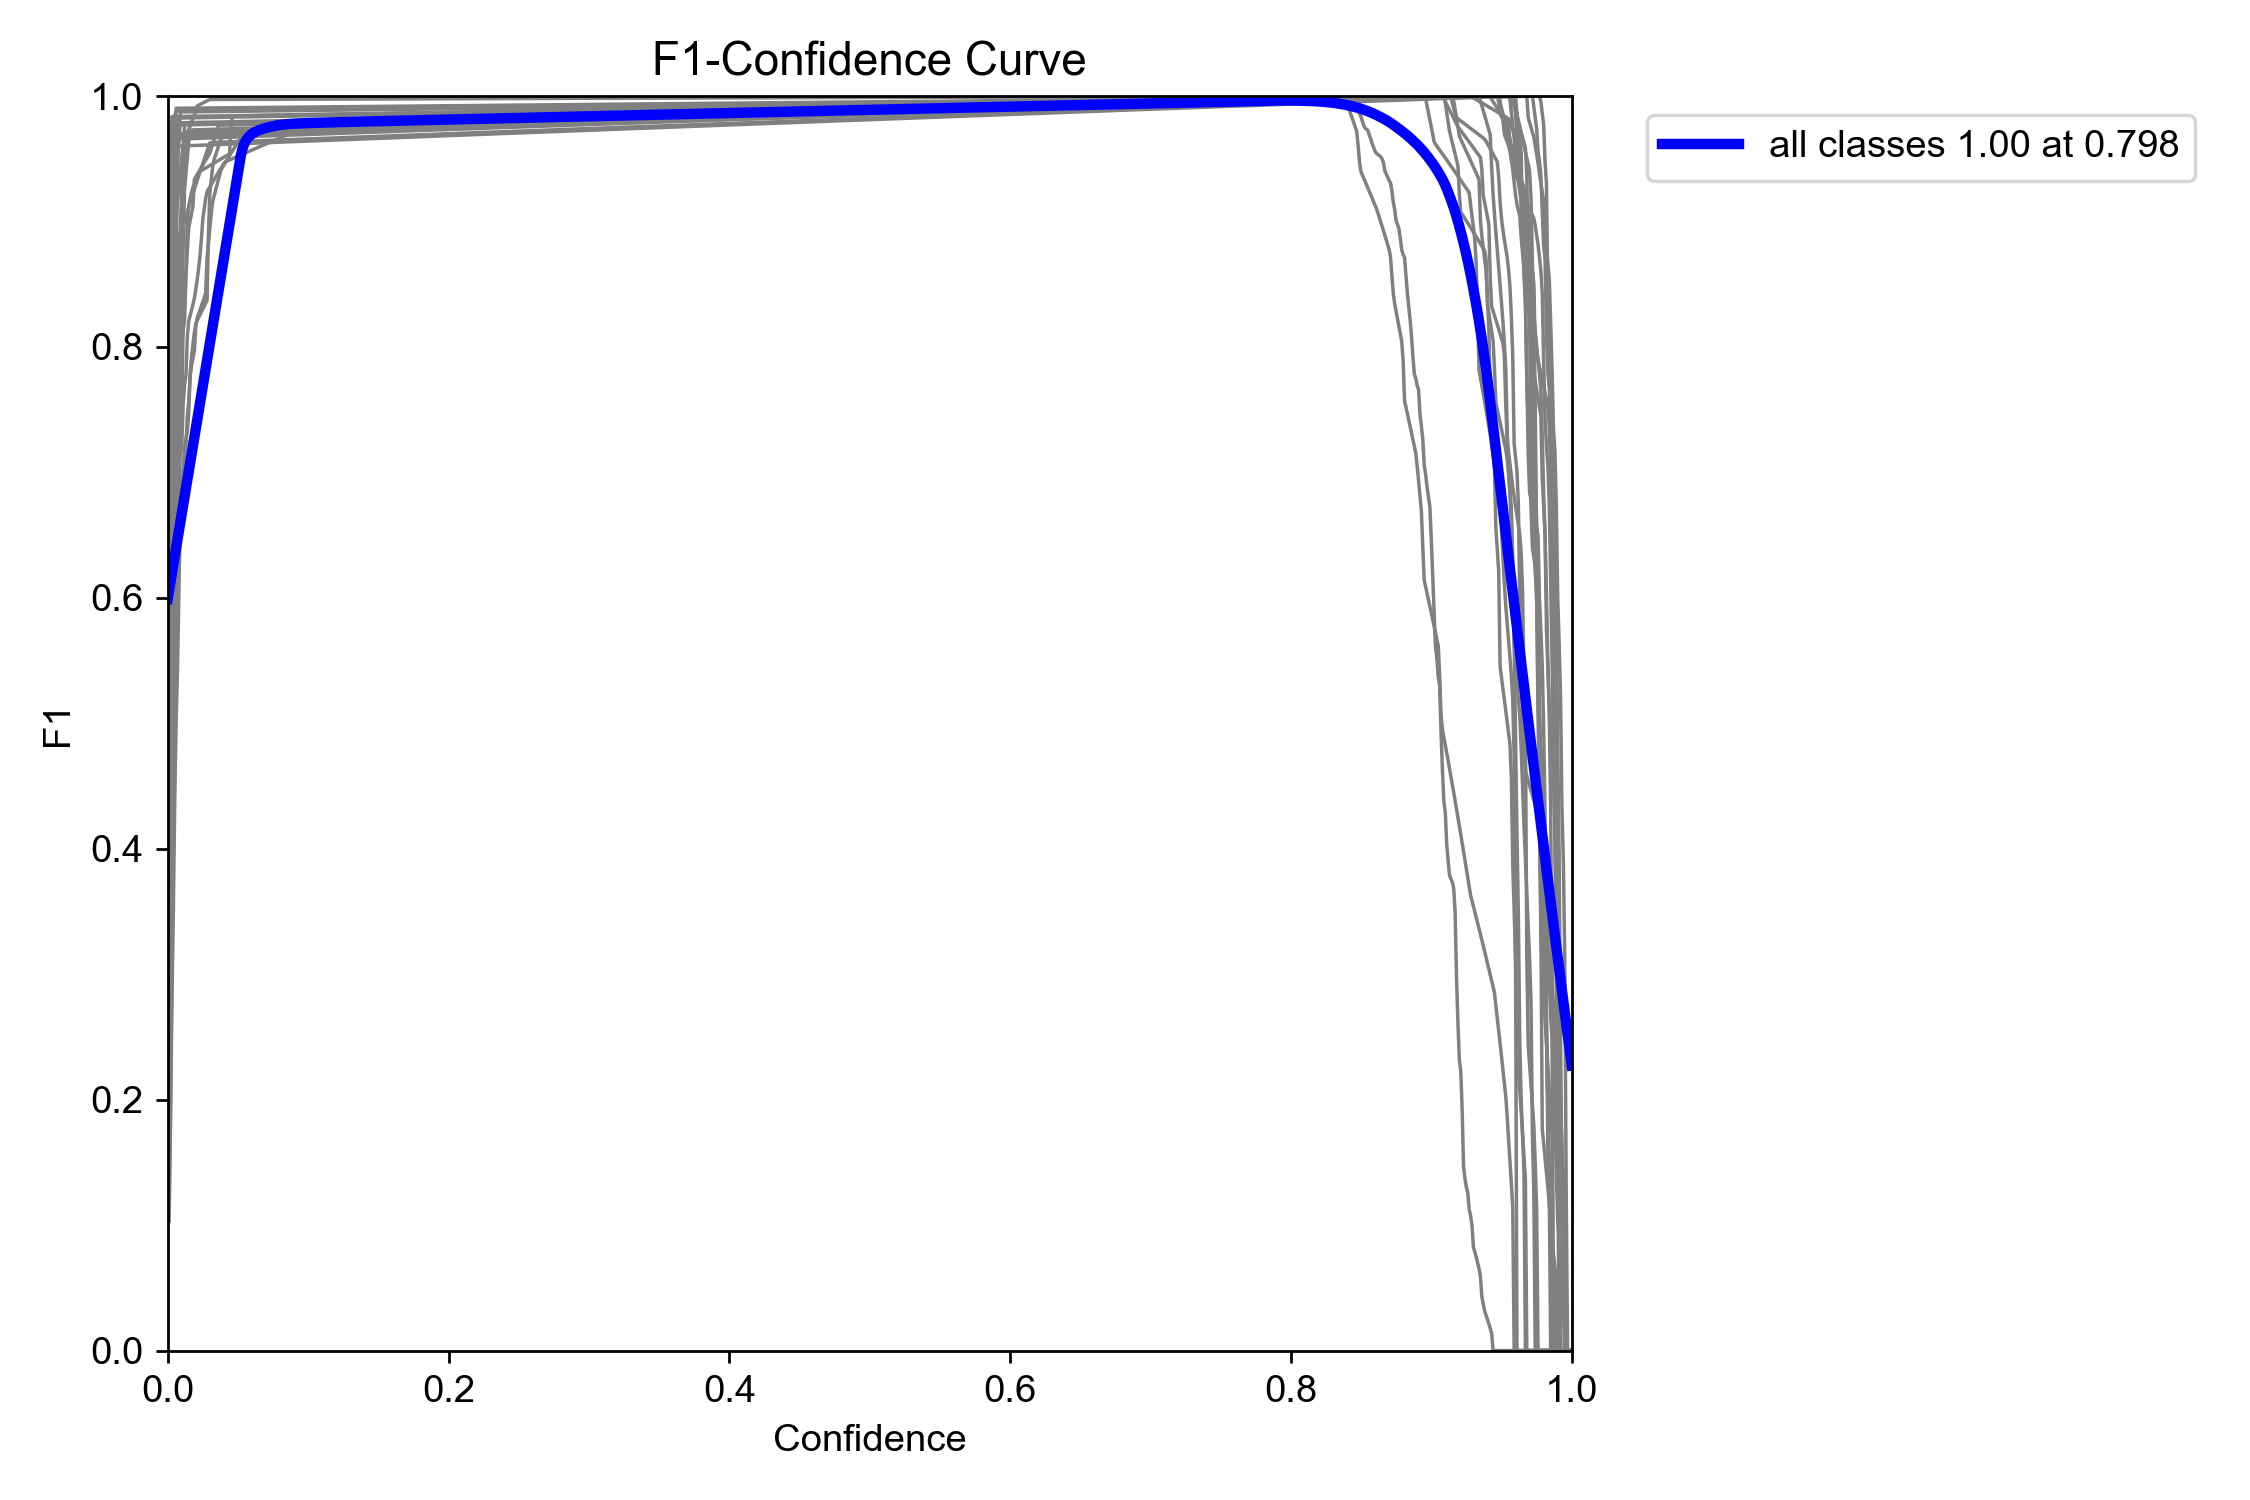

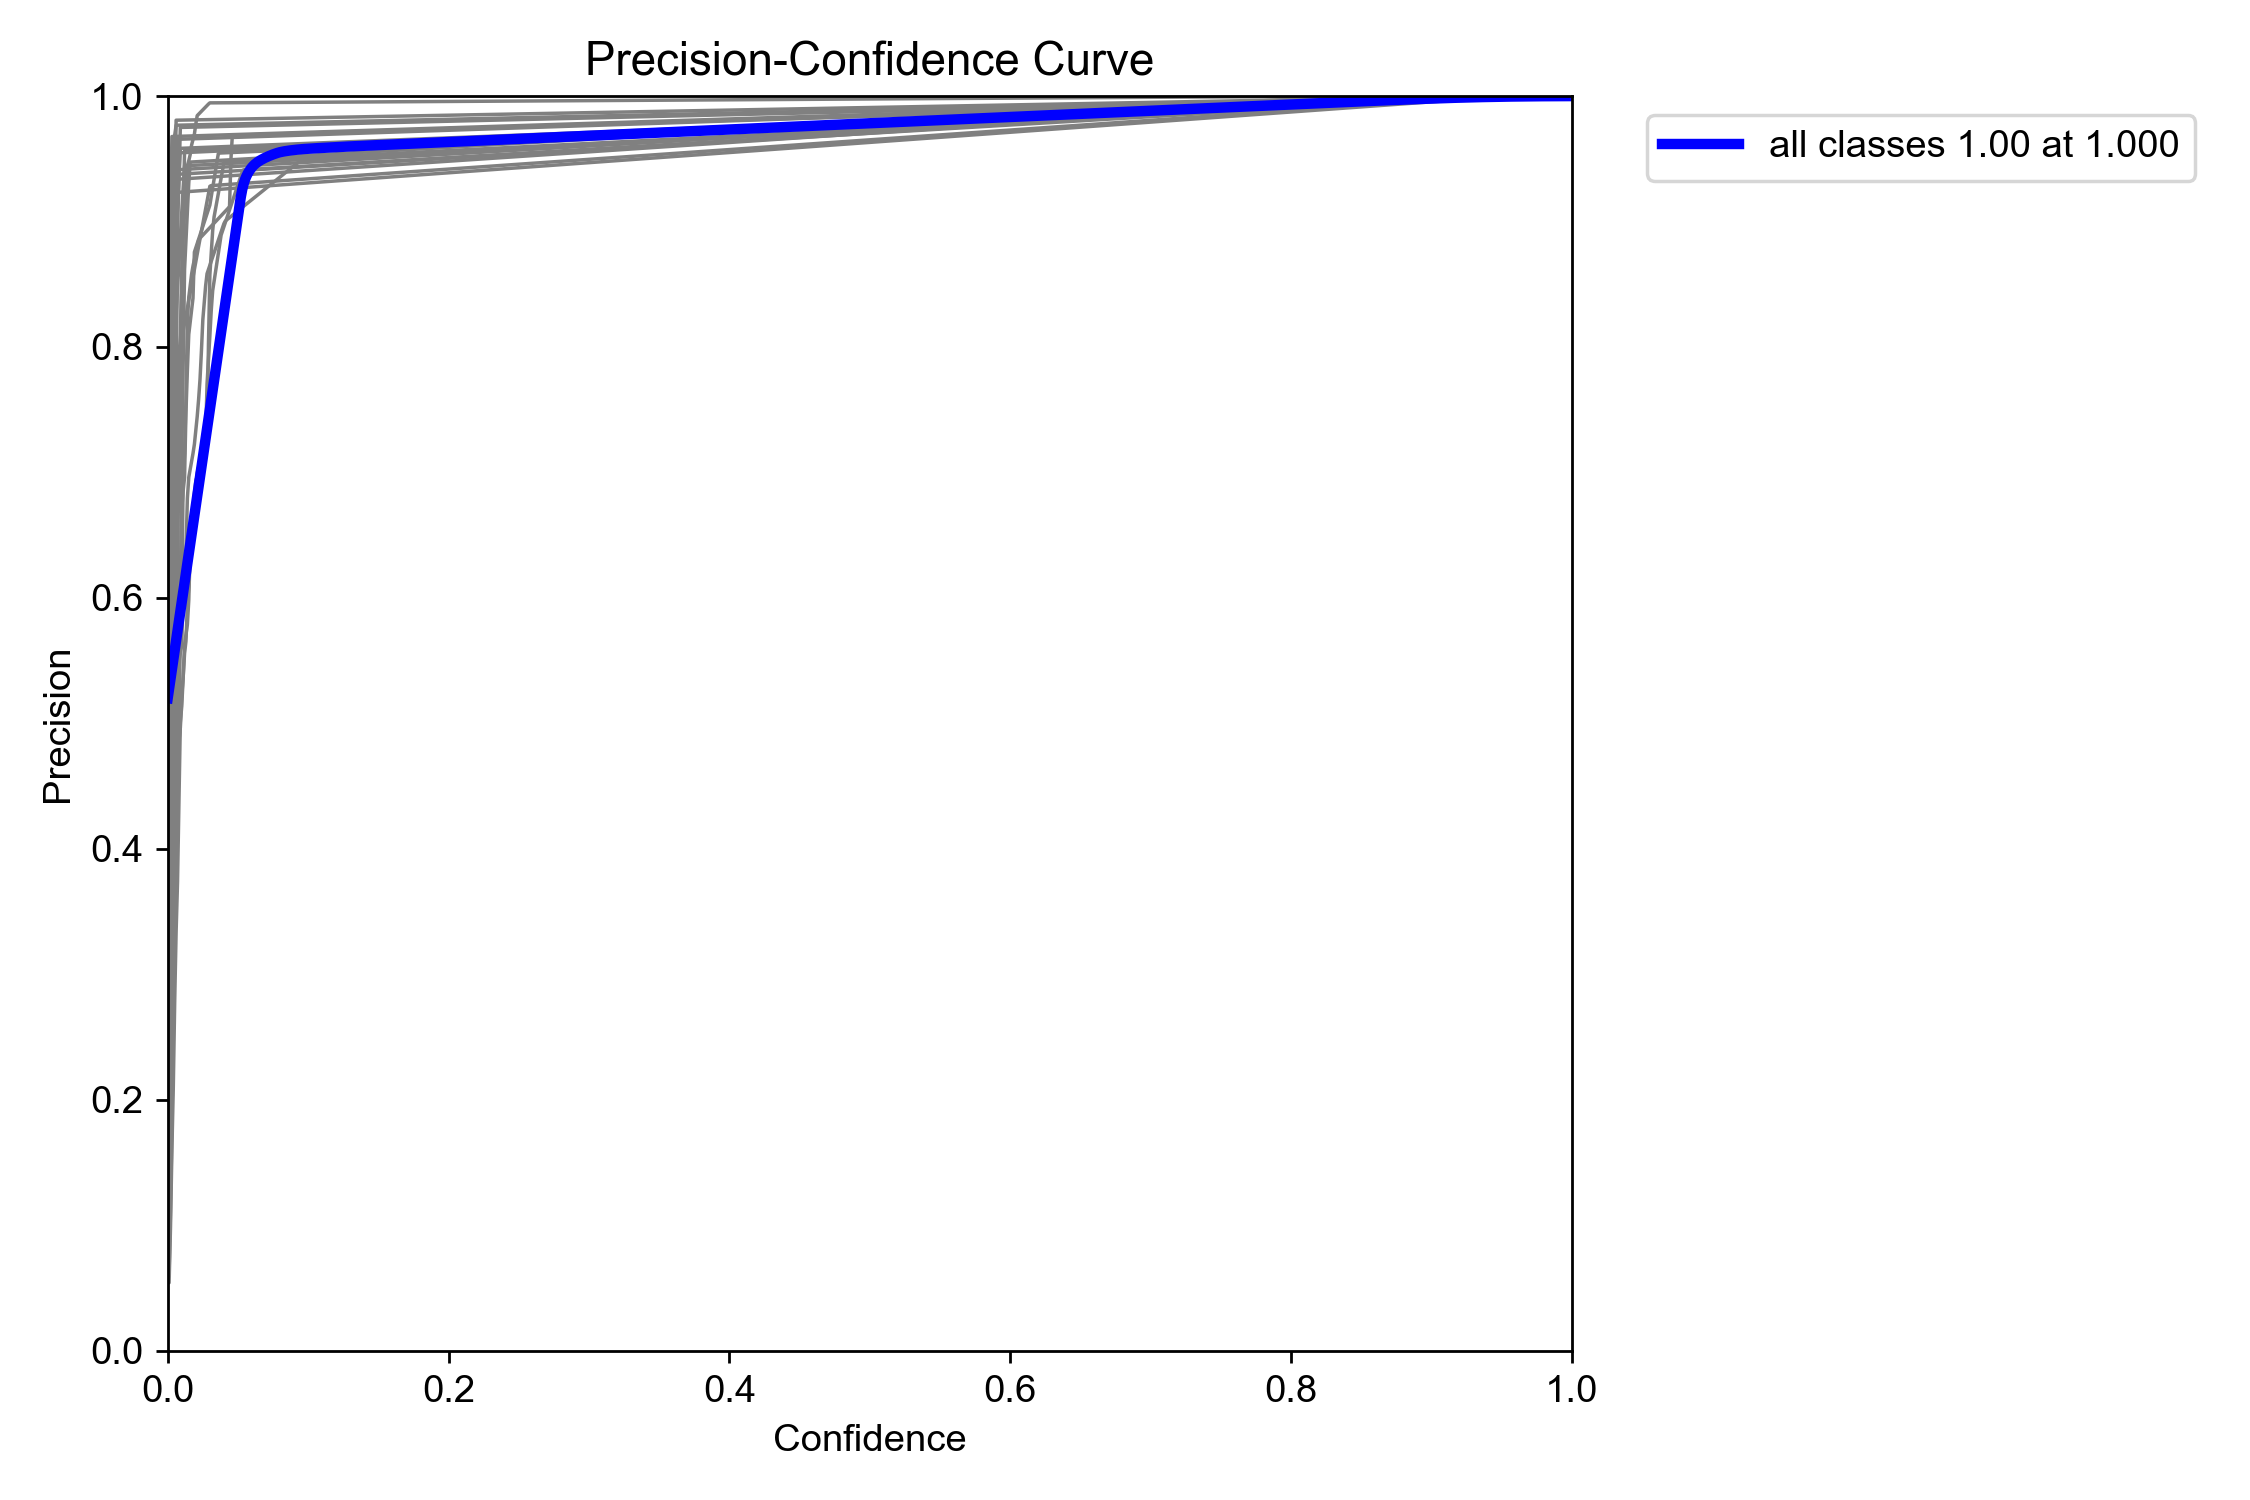

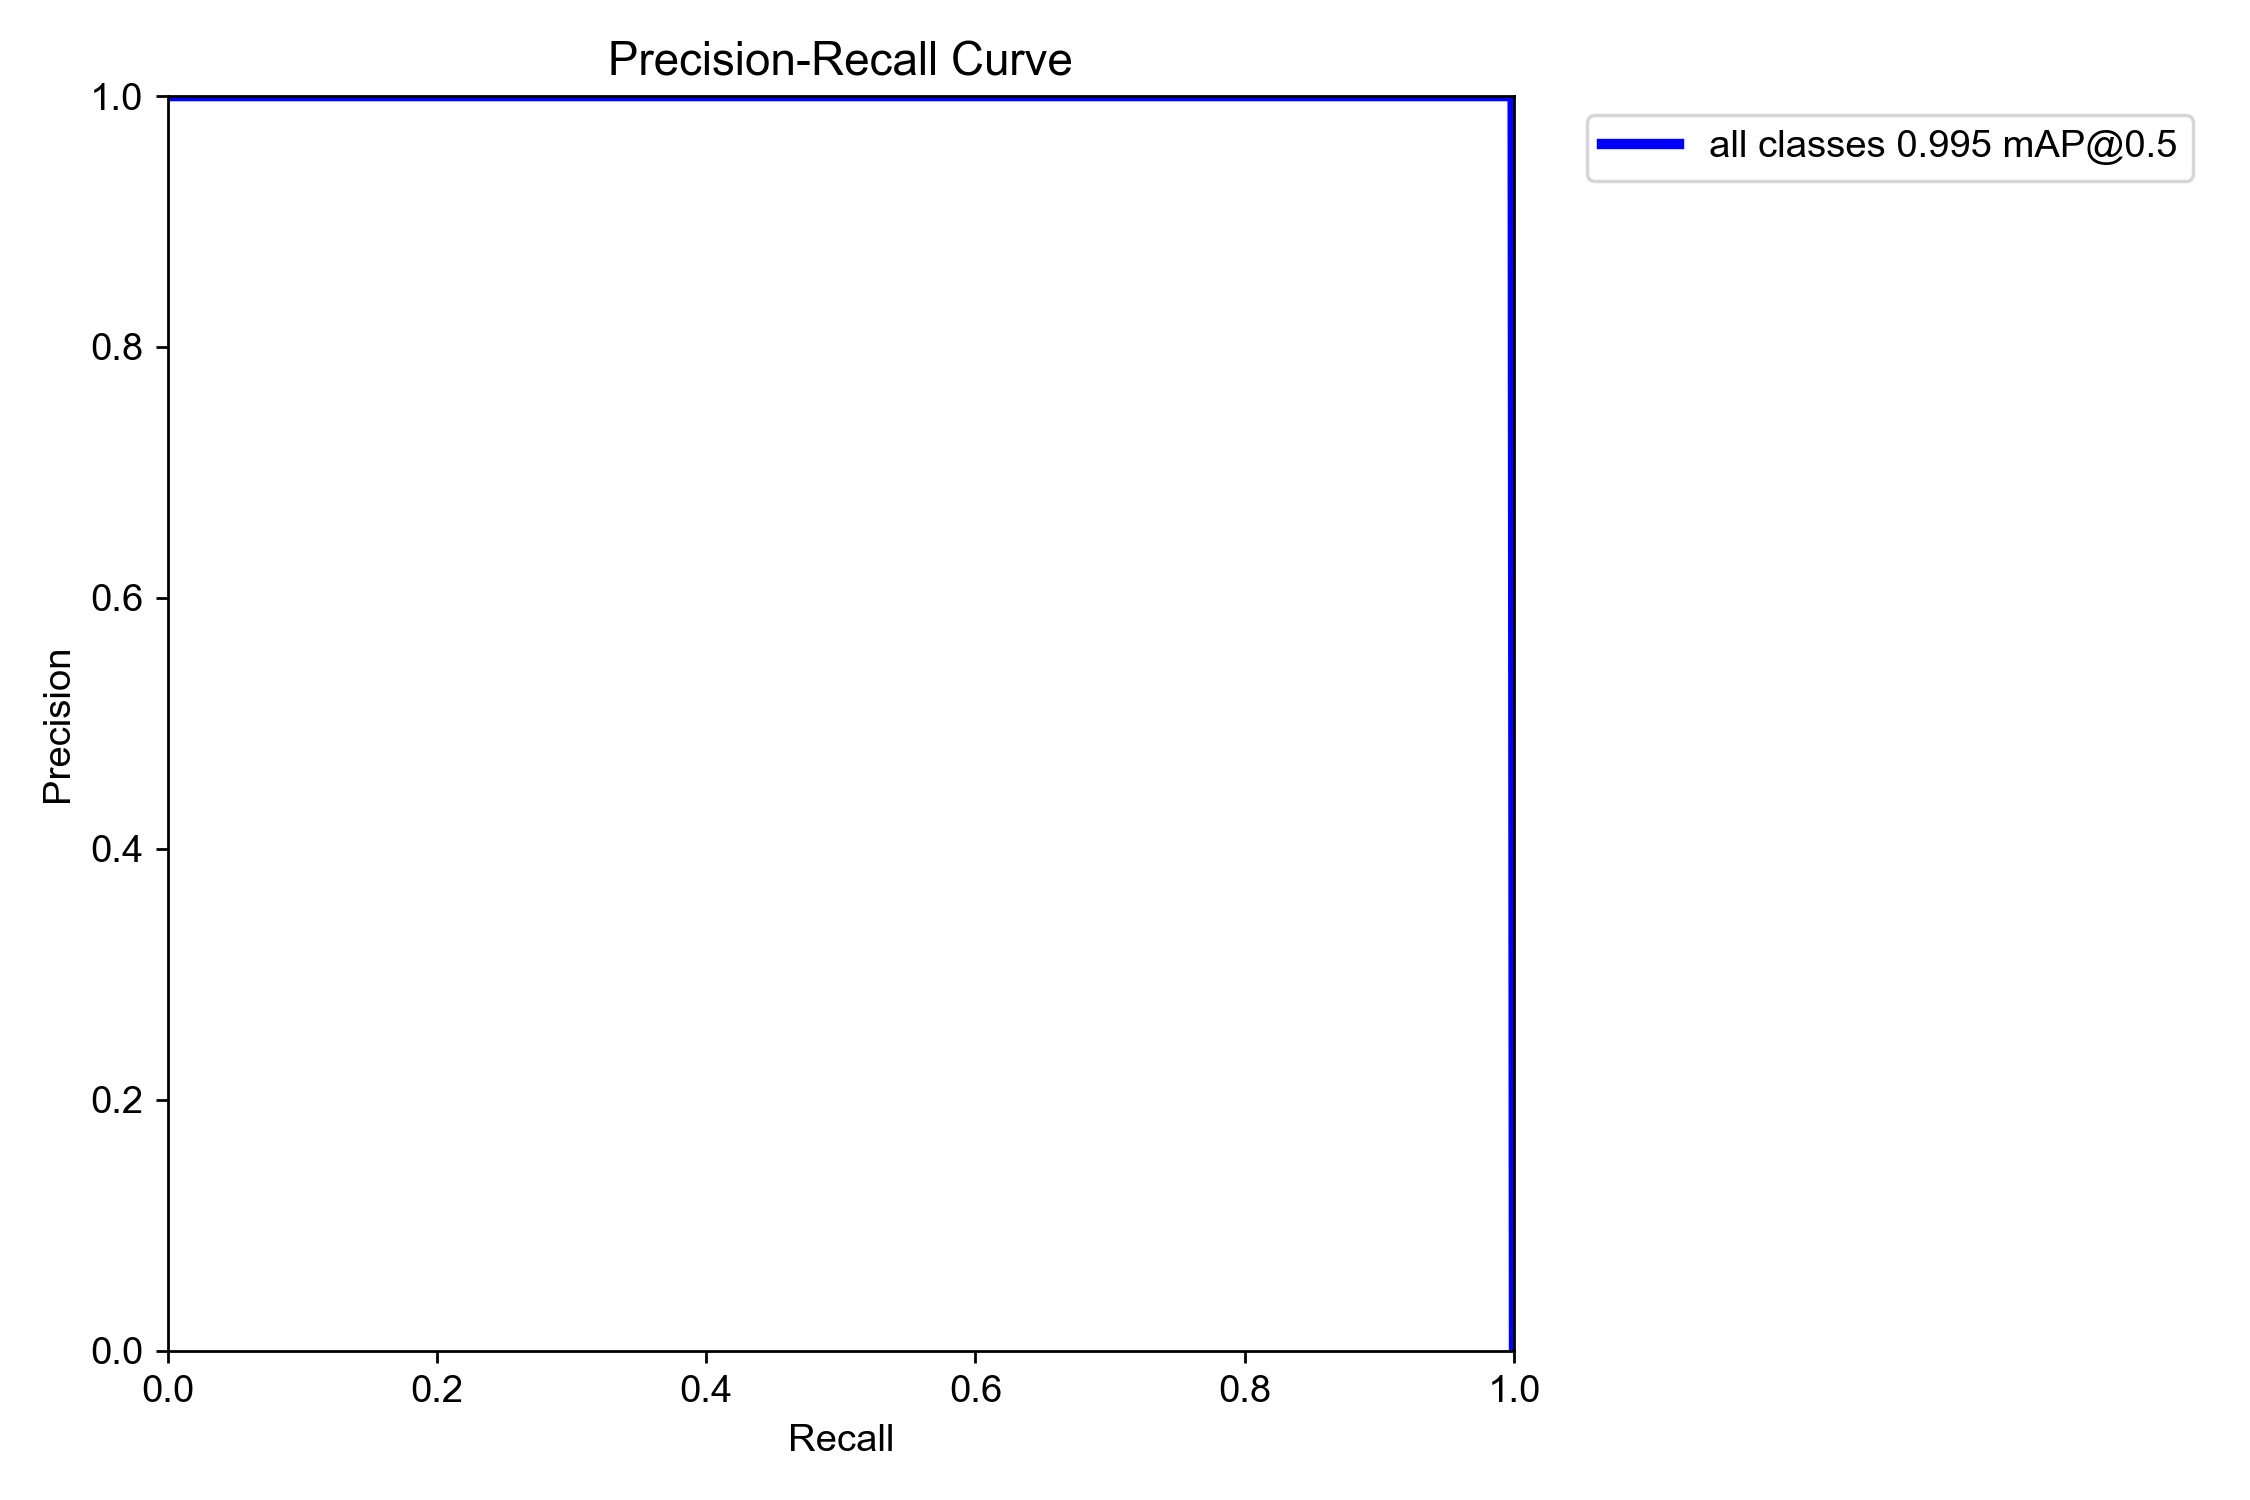

In [ ]:
# ============================================================
# 8. GRAFICAS
# ============================================================

from IPython.display import Image as IPImage, display

results_dir = MODELS_DIR / "yolo_sample_detector"
if not results_dir.exists():
    results_dir = Path("runs/Models/yolo_sample_detector")
if not results_dir.exists():
    results_dir = Path.cwd() / "runs/Models/yolo_sample_detector"
print(f"Buscando graficas en: {results_dir}")
plots = list(results_dir.glob("*.png"))
if plots:
    for plot in plots:
        display(IPImage(filename=str(plot)))
else:
    print("No se encontraron graficas.")

---
## 9. Evaluar en validacion
---

In [ ]:
# ============================================================
# 9. EVALUACION
# ============================================================


if not results_dir.exists():
    for alt in [Path("runs/Models/yolo_sample_detector"), Path.cwd() / "runs/Models/yolo_sample_detector"]:
        if alt.exists():
            results_dir = alt
            break

best_model_path = results_dir / "weights/best.pt"
print(f"Buscando modelo en: {best_model_path}")
if best_model_path.exists():
    model = YOLO(str(best_model_path))
    metrics = model.val(data=str(yaml_path))
    print("\nMetricas:")
    print(f"  mAP50: {metrics.box.map50:.4f}")
    print(f"  mAP50-95: {metrics.box.map:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall: {metrics.box.mr:.4f}")
else:
    print("No hay modelo entrenado aun.")

Buscando modelo en: /Users/adamleanos/Projecto ia - detector de billetes/Models/yolo_sample_detector/weights/best.pt
Ultralytics 8.4.53 🚀 Python-3.8.20 torch-2.4.1 CPU (Apple M2)
Model summary (fused): 73 layers, 3,009,743 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 91.0±8.2 MB/s, size: 28.4 KB)
val: Scanning /Users/adamleanos/Projecto ia - detector de billetes/Data/procesed/yolo_sample_dataset/labels/val.cache... 272 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 272/272 87.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.1it/s 15.2s0.9s
                   all        272        649      0.993          1      0.995      0.958
          animal_100bs         17         17      0.991          1      0.995      0.983
           animal_10bs         21         21      0.992          1      0.995      0.987
          animal_200bs         12         12      0.987       

---
## 10. Inferencia: detectar en una imagen
---

Probando: img_396566.png

image 1/1 /Users/adamleanos/Projecto ia - detector de billetes/notebooks/../Data/procesed/yolo_sample_dataset/images/val/img_396566.png: 320x320 1 serie_a, 1 valor_50bs, 22.5ms
Speed: 0.8ms preprocess, 22.5ms inference, 2.1ms postprocess per image at shape (1, 3, 320, 320)


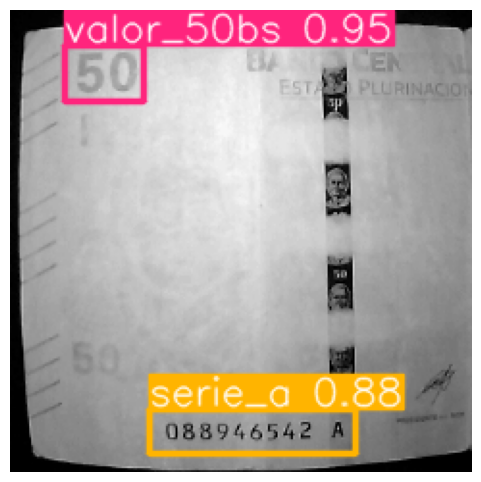


2 detecciones:
  valor_50bs: conf=95.42%  pos=(28,18)-(69,47)
  serie_a: conf=88.41%  pos=(72,207)-(179,230)


In [ ]:
# ============================================================
# 10. INFERENCIA EN UNA IMAGEN
# ============================================================

def detectar(model, image_path, conf=0.55):
    results = model(image_path, conf=conf)
    annotated = results[0].plot(line_width=2, font_size=8)
    plt.figure(figsize=(6, 6))
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()

    boxes = results[0].boxes
    if boxes is not None and len(boxes) > 0:
        print(f"\n{len(boxes)} detecciones:")
        for box in boxes:
            cls_id = int(box.cls[0])
            conf_val = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            print(
                f"  {CLASSES[cls_id]}: conf={conf_val:.2%}"
                f"  pos=({x1},{y1})-({x2},{y2})"
            )
    else:
        print("  Sin detecciones.")
    return results[0]


val_imgs = list((DATASET_OUT / "images/val").glob("*.png"))
if val_imgs:
    ejemplo = random.choice(val_imgs)
    print(f"Probando: {ejemplo.name}")
    detectar(model, str(ejemplo))
else:
    print("No hay imagenes de validacion.")

---
## 11. Auto-etiquetar TODO el dataset DATASET_BILLS_IR

Genera XML Pascal VOC para cada imagen detectada. Las imagenes se copian sin modificar.
---

In [ ]:
# ============================================================
# 11. AUTO-ETIQUETAR DATASET COMPLETO (XML Pascal VOC)
# ============================================================

def auto_etiquetar(model, source_dir, output_dir, conf=0.65):
    source_dir = Path(source_dir)
    output_dir = Path(output_dir)

    imagenes = sorted(source_dir.rglob("*.png"))
    print(f"Procesando {len(imagenes)} imagenes de {source_dir.name}...")

    stats = Counter()
    total_det = 0
    imgs_con_det = 0

    for img_path in imagenes:
        img_pil = Image.open(img_path)
        w, h = img_pil.size
        rel = img_path.relative_to(source_dir)

        out_path_img = output_dir / rel
        out_path_img.parent.mkdir(parents=True, exist_ok=True)
        out_path_xml = out_path_img.with_suffix(".xml")

        results = model(str(img_path), conf=conf, verbose=False)
        boxes = results[0].boxes

        if boxes is not None and len(boxes) > 0:
            imgs_con_det += 1
            total_det += len(boxes)

            annotation = ET.Element("annotation")
            folder = ET.SubElement(annotation, "folder")
            folder.text = str(rel.parent)
            filename = ET.SubElement(annotation, "filename")
            filename.text = img_path.name
            path_elem = ET.SubElement(annotation, "path")
            path_elem.text = str(out_path_img)
            source = ET.SubElement(annotation, "source")
            database = ET.SubElement(source, "database")
            database.text = "YOLOv8 Auto-label"
            size = ET.SubElement(annotation, "size")
            width = ET.SubElement(size, "width")
            width.text = str(w)
            height = ET.SubElement(size, "height")
            height.text = str(h)
            depth = ET.SubElement(size, "depth")
            depth.text = "1"
            segmented = ET.SubElement(annotation, "segmented")
            segmented.text = "0"

            for box in boxes:
                cls_id = int(box.cls[0])
                stats[CLASSES[cls_id]] += 1
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                obj = ET.SubElement(annotation, "object")
                name = ET.SubElement(obj, "name")
                name.text = CLASSES[cls_id]
                pose = ET.SubElement(obj, "pose")
                pose.text = "Unspecified"
                truncated = ET.SubElement(obj, "truncated")
                truncated.text = "0"
                difficult = ET.SubElement(obj, "difficult")
                difficult.text = "0"
                bndbox = ET.SubElement(obj, "bndbox")
                xmin = ET.SubElement(bndbox, "xmin")
                xmin.text = str(x1)
                ymin = ET.SubElement(bndbox, "ymin")
                ymin.text = str(y1)
                xmax = ET.SubElement(bndbox, "xmax")
                xmax.text = str(x2)
                ymax = ET.SubElement(bndbox, "ymax")
                ymax.text = str(y2)

            def indent_xml(elem, level=0):
                i = "\n" + level * "\t"
                if len(elem):
                    if not elem.text or not elem.text.strip():
                        elem.text = i + "\t"
                    if not elem.tail or not elem.tail.strip():
                        elem.tail = i
                    for child in elem:
                        indent_xml(child, level + 1)
                    if not child.tail or not child.tail.strip():
                        child.tail = i
                else:
                    if level and (not elem.tail or not elem.tail.strip()):
                        elem.tail = i

            indent_xml(annotation)
            tree = ET.ElementTree(annotation)
            tree.write(out_path_xml, encoding="utf-8", xml_declaration=True)

        img_pil.save(str(out_path_img))

    print(f"\nProcesado completado")
    print(f"  Imagenes con detecciones: {imgs_con_det}/{len(imagenes)}")
    print(f"  Total detecciones: {total_det}")
    print(f"\nDetecciones por clase:")
    for cls_name, count in stats.most_common():
        print(f"  {cls_name}: {count}")
    print(f"\nXMLs e imagenes guardados en: {output_dir}")


auto_etiquetar(model, FULL_DATASET_DIR, PREDICTIONS_DIR / "anotadas", conf=0.55)

Procesando 4357 imagenes de DATASET_BILLS_IR...

Procesado completado
  Imagenes con detecciones: 4356/4357
  Total detecciones: 10189

Detecciones por clase:
  serie_a: 2905
  valor_ir_200bs: 582
  valor_ir_50bs: 581
  valor_ir_20bs: 580
  valor_ir_100bs: 579
  valor_ir_10bs: 555
  personaje_100bs: 343
  valor_10bs: 297
  valor_50bs: 293
  animal_10bs: 292
  valor_100bs: 291
  personaje_200bs: 291
  personaje_50bs: 291
  animal_200bs: 291
  personaje_20bs: 290
  animal_20bs: 290
  animal_50bs: 290
  personaje_10bs: 289
  animal_100bs: 289
  valor_200bs: 286
  valor_20bs: 284

XMLs e imagenes guardados en: ../Data/procesed/predictions_auto/anotadas


---
## 15. Extraer segmentos (crops) organizados por denominacion/lado/etiqueta

```
segmentos_ir_billetes/
  10_Bs/
    anverso/
      personaje_10bs/
      valor_10bs/
      serie_a/
      ...
    reverso/ ...
  20_Bs/ ...
```
---


In [ ]:
# ============================================================
# 15. EXTRAER SEGMENTOS (CROPS) DEL DATASET AUTO-ETIQUETADO
# ============================================================

from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
from collections import defaultdict

SOURCE_DIR = Path("../Data/raw/DATASET_BILLS_IR_PROCESADO/anotadas")
SEGMENTS_DIR = Path("../Data/raw/segmentos_ir_billetes")
MIN_CONF = 0.5  # confianza minima para extraer

# Encontre best.pt del ultimo modelo
from ultralytics import YOLO
BEST = Path("../Models") / "yolo_full_detector" / "weights/best.pt"
for alt in [Path("runs/Models/yolo_full_detector"), Path.cwd() / "runs/Models/yolo_full_detector"]:
    alt_best = alt / "weights/best.pt"
    if alt_best.exists():
        BEST = alt_best
        break

if not BEST.exists():
    # Buscar cualquier best.pt de yolo_full
    for p in sorted(Path("..").rglob("**/yolo_full_detector/weights/best.pt")):
        BEST = p
        break

print(f"Modelo: {BEST}")
model = YOLO(str(BEST))

# Escanear imagenes
imagenes = sorted(SOURCE_DIR.rglob("*.png"))
print(f"Procesando {len(imagenes)} imagenes...")

stats = defaultdict(int)
total_crops = 0

for img_path in imagenes:
    img = Image.open(img_path)
    w, h = img.size

    # Extraer denominacion y lado del path
    #   .../3._BillsIR_-_LadoA_-_Anverso/100_Bs_IR/img_xxx.png
    rel = img_path.relative_to(SOURCE_DIR)
    parts = rel.parts

    # Denominacion
    denom = parts[-2].replace("_IR", "")  # 100_Bs_IR -> 100_Bs

    # Lado: anverso o reverso
    lado_folder = parts[-3]  # 3._BillsIR_-_LadoA_-_Anverso
    if "Reverso" in lado_folder:
        lado = "reverso"
    else:
        lado = "anverso"

    # Inferir
    results = model(str(img_path), conf=MIN_CONF, verbose=False)
    boxes = results[0].boxes

    if boxes is None or len(boxes) == 0:
        continue

    for box in boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = model.names[cls_id]

        # Crop
        crop = img.crop((x1, y1, x2, y2))

        out_dir = SEGMENTS_DIR / denom / lado / label
        out_dir.mkdir(parents=True, exist_ok=True)

        crop_name = f"{img_path.stem}_{label}_{conf:.2f}.png"
        crop.save(str(out_dir / crop_name))

        stats[f"{denom}/{lado}/{label}"] += 1
        total_crops += 1

print(f"\nExtraidos {total_crops} segmentos en {SEGMENTS_DIR}")
print(f"\nPor denominacion:")
for denom in sorted(set(k.split("/")[0] for k in stats.keys())):
    count = sum(v for k, v in stats.items() if k.startswith(denom + "/"))
    print(f"  {denom}: {count}")
print(f"\nEstructura:")
for path_dir in sorted(SEGMENTS_DIR.rglob("*")):
    if path_dir.is_dir():
        n = len(list(path_dir.glob("*.png")))
        if n > 0:
            rel_path = path_dir.relative_to(SEGMENTS_DIR)
            print(f"  {rel_path}/ ({n} crops)")